In [1]:
import time
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import emoji, re, string

import nltk
from nltk.corpus import stopwords
import spacy

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, AutoModel
import evaluate
import torch
import numpy as np

import warnings
warnings.filterwarnings("ignore")
sns.set(style="darkgrid")

from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

d:\Arquivos_Acer\Documents\UFC\PrejudicePT-br-main\ambiente_prejudice\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../../Datasets/Correto_whatsapp_rotulado_revisado.csv')
df.head()

,text_content_anonymous,preconceito
0,Show :clapping_hands_light_skin_tone::clapping...,0
1,Mais uma vez o PT= Partido das Trevas apela ao...,1
2,Se não puder avise só para não quebrar a vigíl...,0
3,E a esquerda tenta impedir o trabalho,0
4,Deus perdoa porque eles Não sabem que fazem e ...,0


In [3]:
df.shape

(3000, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   text_content_anonymous  3000 non-null   object
 1   preconceito             3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [5]:
mensagens_coluna = 'text_content_anonymous'  
df[mensagens_coluna] = df[mensagens_coluna].astype(str) # garantindo que todos os valores são strings

# Tokenizar mensagens (simples divisão por espaços)
df['num_tokens'] = df[mensagens_coluna].apply(lambda x: len(x.split()))

## Processamento do texto

In [6]:
unicode_emoji = {}
for key, value in emoji.EMOJI_DATA.items():
    try:
        unicode_emoji[key] = value['pt']
    except:
        pass

#emojis and punctuation
emojis_list = list(unicode_emoji)
punct = list(string.punctuation)
emojis_punct = emojis_list + punct

def processEmojisPunctuation(text, remove_punct = True):
    '''
    Put spaces between emojis. Removes punctuation.
    '''
    #get all unique chars
    chars = set(text)
    #for each unique char in text, do:
    for c in chars:
        #remove punctuation
        if remove_punct:
            if c in emojis_list:
                text = text.replace(c, ' ' + c + ' ')
            if c in punct:
                text = text.replace(c, ' ')

        #put spaces between punctuation
        else:
            if c in emojis_punct:
                text = text.replace(c, ' ' + c + ' ')          

    text = text.replace('  ', ' ')
    return text

#stop words removal
stop_words = list(stopwords.words('portuguese'))
new_stopwords = ['aí','pra','vão','vou','onde','lá','aqui',
                'tá','pode','pois','so','deu','agora','todo',
                'nao','ja','vc', 'bom', 'ai','kkk','kkkk','ta', 'voce', 'alguem', 'ne', 'pq',
                'cara','to','mim','la','vcs','tbm', 'tudo']
stop_words = stop_words + new_stopwords
final_stop_words = []
for sw in stop_words:
    sw = ' '+ sw + ' '
    final_stop_words.append(sw)

def removeStopwords(text):
    for sw in final_stop_words:
        text = text.replace(sw,' ')
    text = text.replace('  ',' ')
    return text

#lemmatization
nlp = spacy.load('pt_core_news_sm')
def lemmatization(text):
    doc = nlp(text)
    for token in doc:
        if token.text != token.lemma_:
            text = text.replace(token.text, token.lemma_)
    return text


def domainUrl(text):
    '''
    Substitutes an URL in a text for the domain of this URL
    Input: an string
    Output: the string with the modified URL
    '''    
    if 'http' in text:
        re_url = '[^\s]*https*://[^\s]*'
        matches = re.findall(re_url, text, flags=re.IGNORECASE)
        for m in matches:
            domain = m.split('//')
            domain = domain[1].split('/')[0]
            text = re.sub(re_url, domain, text, 1)
        return text
    else:
        return text 

def preprocess(text):
    text = text.lower().strip()
    text = domainUrl(text)
    text = processEmojisPunctuation(text)
    text = removeStopwords(text)
    text = lemmatization(text)
    return text


In [7]:
# === Renomeando colunas ===
df = df[["text_content_anonymous", "preconceito"]].rename(columns={
    "text_content_anonymous": "text",
    "preconceito": "label"
})
df["label"] = df["label"].astype(int)


In [8]:
df.head()

,text,label
0,Show :clapping_hands_light_skin_tone::clapping...,0
1,Mais uma vez o PT= Partido das Trevas apela ao...,1
2,Se não puder avise só para não quebrar a vigíl...,0
3,E a esquerda tenta impedir o trabalho,0
4,Deus perdoa porque eles Não sabem que fazem e ...,0


In [9]:
# Função de pré-processamento
def preprocess_data(df, experiment):
    if 'processed' in experiment:
        print("Pré-processamento ativado.")
        pro_texts = [preprocess(t) for t in df['text']]
    else:
        print("Sem pré-processamento.")
        pro_texts = [processEmojisPunctuation(t.lower(), remove_punct=False) for t in df['text']]
    return pro_texts


In [10]:
classifiers = {
    "GaussianNB": GaussianNB(),
    #"LogisticRegression": LogisticRegression(max_iter=1000),
    #"LinearSVC": LinearSVC(dual="auto", max_iter=10000, random_state=42),
    #"KNN": KNeighborsClassifier(),
    #"SGDClassifier": SGDClassifier(),
    #"RandomForest": RandomForestClassifier(),
    #"GradientBoosting": GradientBoostingClassifier(),
    #"MLP": MLPClassifier(max_iter=300)
}

## Modelos Pré treinados - Sem pré processamento

In [11]:
# === Pré-processamento dinâmico ===
df["text"] = preprocess_data(df, experiment="raw")  
df.head()

Sem pré-processamento.


,text,label
0,show : clapping _ hands _ light _ skin _ tone ...,0
1,mais uma vez o pt = partido das trevas apela a...,1
2,se não puder avise só para não quebrar a vigíl...,0
3,e a esquerda tenta impedir o trabalho,0
4,deus perdoa porque eles não sabem que fazem e ...,0


### melll-uff/bertweetbr

In [12]:

# === Configurações ===

model_name = "melll-uff/bertweetbr"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    use_safetensors=True # não usa toach.load
    )
model.eval()  # modo avaliação

def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls_last4"):
    inputs = tokenizer(
        texts, 
        padding=True, 
        truncation=True, 
        max_length=128, 
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states  # lista de camadas
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]

        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)

        elif pooling == "max":
            embeddings = last_hidden.max(dim=1).values

        elif pooling == "mean_max":
            mean_emb = last_hidden.mean(dim=1)
            max_emb = last_hidden.max(dim=1).values
            embeddings = torch.cat([mean_emb, max_emb], dim=1)

        elif pooling == "cls_last4":
            # média das últimas 4 camadas do CLS
            last_four = hidden_states[-4:]
            stacked = torch.stack(last_four, dim=0)  # [4, batch, seq_len, hidden]
            embeddings = torch.mean(stacked, dim=0)[:, 0, :]

        else:
            raise ValueError("Pooling deve ser 'cls', 'mean', 'max', 'mean_max' ou 'cls_last4'")

    return embeddings.cpu().numpy()



texts = df["text"].tolist()
labels = df["label"].values

X_embeddings = get_embeddings(texts, tokenizer, model, pooling="cls_last4")
y = labels




skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

experiments_start_time = time.time()

for clf_name, clf in classifiers.items():
    print(f"\n=== {clf_name} ===")
    fold_metrics = []
    
    
    for train_idx, test_idx in skf.split(X_embeddings, y):
        X_train, X_test = X_embeddings[train_idx], X_embeddings[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        # Probabilidades ou scores para AUC
        if hasattr(clf, "predict_proba"):
            y_scores = clf.predict_proba(X_test)[:, 1]
        elif hasattr(clf, "decision_function"):
            y_scores = clf.decision_function(X_test)
        else:
            y_scores = None  # se o modelo não tiver, pula AUC

        # Algumas métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        if y_scores is not None:
            auc = roc_auc_score(y_test, y_scores)
        else:
            auc = np.nan

        fold_metrics.append([acc, prec, rec, f1, auc])
    
    
    fold_metrics = np.array(fold_metrics, dtype=np.float64)
    mean_metrics = np.nanmean(fold_metrics, axis=0)  # ignora NaN se algum modelo não tiver AUC
    std_metrics = np.nanstd(fold_metrics, axis=0)
    vocab_size = X_embeddings.shape[1]

    results.append([
        clf_name,
        *mean_metrics,
        *std_metrics,
        vocab_size
    ])

# Tempo total do experimento
experiment_time = time.time() - experiments_start_time

# Organiza resultados em DataFrame
results_df = pd.DataFrame(
    results, 
    columns=[
        "Modelo", 
        "Accuracy_mean", "Precision_mean", "Recall_mean", "F1_mean", "AUC_mean",
        "Accuracy_std", "Precision_std", "Recall_std", "F1_std", "AUC_std",
        "Vocab_size"
    ]
)

results_df['total_experiment_time_sec'] = experiment_time

print(results_df)

results_df.to_csv('./resultados/results_melll_uff_Sempre_processamento_gaussian.csv', index=False)

Some weights of RobertaModel were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



=== GaussianNB ===
       Modelo  Accuracy_mean  Precision_mean  Recall_mean   F1_mean  AUC_mean  \
0  GaussianNB       0.663333        0.631282     0.786667  0.699916   0.75604   

   Accuracy_std  Precision_std  Recall_std    F1_std   AUC_std  Vocab_size  \
0      0.017857       0.014946     0.04174  0.020213  0.016048         768   

   total_experiment_time_sec  
0                   0.555795  


### FpOliveira/tupi-bert-base-portuguese-cased

In [13]:
# === Configurações ===

model_name = "FpOliveira/tupi-bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    use_safetensors=True # não usa toach.load
    )
model.eval()  # modo avaliação

def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls_last4"):
    inputs = tokenizer(
        texts, 
        padding=True, 
        truncation=True, 
        max_length=128, 
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states  # lista de camadas
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]

        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)

        elif pooling == "max":
            embeddings = last_hidden.max(dim=1).values

        elif pooling == "mean_max":
            mean_emb = last_hidden.mean(dim=1)
            max_emb = last_hidden.max(dim=1).values
            embeddings = torch.cat([mean_emb, max_emb], dim=1)

        elif pooling == "cls_last4":
            # média das últimas 4 camadas do CLS
            last_four = hidden_states[-4:]
            stacked = torch.stack(last_four, dim=0)  # [4, batch, seq_len, hidden]
            embeddings = torch.mean(stacked, dim=0)[:, 0, :]

        else:
            raise ValueError("Pooling deve ser 'cls', 'mean', 'max', 'mean_max' ou 'cls_last4'")

    return embeddings.cpu().numpy()



texts = df["text"].tolist()
labels = df["label"].values

X_embeddings = get_embeddings(texts, tokenizer, model, pooling="cls_last4")
y = labels




skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

experiments_start_time = time.time()

for clf_name, clf in classifiers.items():
    print(f"\n=== {clf_name} ===")
    fold_metrics = []
    
    
    for train_idx, test_idx in skf.split(X_embeddings, y):
        X_train, X_test = X_embeddings[train_idx], X_embeddings[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        # Probabilidades ou scores para AUC
        if hasattr(clf, "predict_proba"):
            y_scores = clf.predict_proba(X_test)[:, 1]
        elif hasattr(clf, "decision_function"):
            y_scores = clf.decision_function(X_test)
        else:
            y_scores = None  # se o modelo não tiver, pula AUC

        # Algumas métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        if y_scores is not None:
            auc = roc_auc_score(y_test, y_scores)
        else:
            auc = np.nan

        fold_metrics.append([acc, prec, rec, f1, auc])
    
    
    fold_metrics = np.array(fold_metrics, dtype=np.float64)
    mean_metrics = np.nanmean(fold_metrics, axis=0)  # ignora NaN se algum modelo não tiver AUC
    std_metrics = np.nanstd(fold_metrics, axis=0)
    vocab_size = X_embeddings.shape[1]

    results.append([
        clf_name,
        *mean_metrics,
        *std_metrics,
        vocab_size
    ])

# Tempo total do experimento
experiment_time = time.time() - experiments_start_time

# Organiza resultados em DataFrame
results_df = pd.DataFrame(
    results, 
    columns=[
        "Modelo", 
        "Accuracy_mean", "Precision_mean", "Recall_mean", "F1_mean", "AUC_mean",
        "Accuracy_std", "Precision_std", "Recall_std", "F1_std", "AUC_std",
        "Vocab_size"
    ]
)

results_df['total_experiment_time_sec'] = experiment_time

print(results_df)
results_df.to_csv('./resultados/results_FpOliveira_Sempre_processamento_gaussian.csv', index=False)


=== GaussianNB ===
       Modelo  Accuracy_mean  Precision_mean  Recall_mean   F1_mean  AUC_mean  \
0  GaussianNB       0.819667        0.844373        0.784  0.812968  0.872892   

   Accuracy_std  Precision_std  Recall_std    F1_std   AUC_std  Vocab_size  \
0      0.011757       0.014439    0.016111  0.012543  0.011894         768   

   total_experiment_time_sec  
0                   0.562403  


### ruanchaves/bert-base-portuguese-cased-hatebr

In [14]:
# === Configurações ===

model_name = "ruanchaves/bert-base-portuguese-cased-hatebr"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    use_safetensors=True # não usa toach.load
    )
model.eval()  # modo avaliação

def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls_last4"):
    inputs = tokenizer(
        texts, 
        padding=True, 
        truncation=True, 
        max_length=128, 
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states  # lista de camadas
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]

        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)

        elif pooling == "max":
            embeddings = last_hidden.max(dim=1).values

        elif pooling == "mean_max":
            mean_emb = last_hidden.mean(dim=1)
            max_emb = last_hidden.max(dim=1).values
            embeddings = torch.cat([mean_emb, max_emb], dim=1)

        elif pooling == "cls_last4":
            # média das últimas 4 camadas do CLS
            last_four = hidden_states[-4:]
            stacked = torch.stack(last_four, dim=0)  # [4, batch, seq_len, hidden]
            embeddings = torch.mean(stacked, dim=0)[:, 0, :]

        else:
            raise ValueError("Pooling deve ser 'cls', 'mean', 'max', 'mean_max' ou 'cls_last4'")

    return embeddings.cpu().numpy()


texts = df["text"].tolist()
labels = df["label"].values

X_embeddings = get_embeddings(texts, tokenizer, model, pooling="cls_last4")
y = labels




skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

experiments_start_time = time.time()

for clf_name, clf in classifiers.items():
    print(f"\n=== {clf_name} ===")
    fold_metrics = []
    
    
    for train_idx, test_idx in skf.split(X_embeddings, y):
        X_train, X_test = X_embeddings[train_idx], X_embeddings[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        # Probabilidades ou scores para AUC
        if hasattr(clf, "predict_proba"):
            y_scores = clf.predict_proba(X_test)[:, 1]
        elif hasattr(clf, "decision_function"):
            y_scores = clf.decision_function(X_test)
        else:
            y_scores = None  # se o modelo não tiver, pula AUC

        # Algumas métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        if y_scores is not None:
            auc = roc_auc_score(y_test, y_scores)
        else:
            auc = np.nan

        fold_metrics.append([acc, prec, rec, f1, auc])
    
    
    fold_metrics = np.array(fold_metrics, dtype=np.float64)
    mean_metrics = np.nanmean(fold_metrics, axis=0)  # ignora NaN se algum modelo não tiver AUC
    std_metrics = np.nanstd(fold_metrics, axis=0)
    vocab_size = X_embeddings.shape[1]

    results.append([
        clf_name,
        *mean_metrics,
        *std_metrics,
        vocab_size
    ])

# Tempo total do experimento
experiment_time = time.time() - experiments_start_time

# Organiza resultados em DataFrame
results_df = pd.DataFrame(
    results, 
    columns=[
        "Modelo", 
        "Accuracy_mean", "Precision_mean", "Recall_mean", "F1_mean", "AUC_mean",
        "Accuracy_std", "Precision_std", "Recall_std", "F1_std", "AUC_std",
        "Vocab_size"
    ]
)

results_df['total_experiment_time_sec'] = experiment_time

print(results_df)
results_df.to_csv('./resultados/results_ruanChaves_Sempre_processamento_gaussian.csv', index=False)


=== GaussianNB ===
       Modelo  Accuracy_mean  Precision_mean  Recall_mean   F1_mean  AUC_mean  \
0  GaussianNB       0.761333        0.745861     0.793333  0.768722  0.778468   

   Accuracy_std  Precision_std  Recall_std    F1_std   AUC_std  Vocab_size  \
0      0.018055       0.019144    0.021602  0.017397  0.019635         768   

   total_experiment_time_sec  
0                   0.521462  


## Modelo pré treinados - Com pré processamento

In [15]:
# === Pré-processamento dinâmico ===
df["text"] = preprocess_data(df, experiment="processed")  
df.head()

Pré-processamento ativado.


,text,label
0,show clapping handsrrrrr light skin tone clap...,0
1,mais vez pt partir treva apelar mp proibir esc...,1
2,se puder aviserr quebrar vigíliar \n\n“pai est...,0
3,e esquerda tentar impedir trabalho,0
4,Deus perdoa porque saber fazer falar pronto as...,0


### melll-uff/bertweetbr

In [16]:

# === Configurações ===

model_name = "melll-uff/bertweetbr"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    use_safetensors=True # não usa toach.load
    )
model.eval()  # modo avaliação

def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls_last4"):
    inputs = tokenizer(
        texts, 
        padding=True, 
        truncation=True, 
        max_length=128, 
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states  # lista de camadas
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]

        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)

        elif pooling == "max":
            embeddings = last_hidden.max(dim=1).values

        elif pooling == "mean_max":
            mean_emb = last_hidden.mean(dim=1)
            max_emb = last_hidden.max(dim=1).values
            embeddings = torch.cat([mean_emb, max_emb], dim=1)

        elif pooling == "cls_last4":
            # média das últimas 4 camadas do CLS
            last_four = hidden_states[-4:]
            stacked = torch.stack(last_four, dim=0)  # [4, batch, seq_len, hidden]
            embeddings = torch.mean(stacked, dim=0)[:, 0, :]

        else:
            raise ValueError("Pooling deve ser 'cls', 'mean', 'max', 'mean_max' ou 'cls_last4'")

    return embeddings.cpu().numpy()



texts = df["text"].tolist()
labels = df["label"].values

X_embeddings = get_embeddings(texts, tokenizer, model, pooling="cls_last4")
y = labels




skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

experiments_start_time = time.time()

for clf_name, clf in classifiers.items():
    print(f"\n=== {clf_name} ===")
    fold_metrics = []
    
    
    for train_idx, test_idx in skf.split(X_embeddings, y):
        X_train, X_test = X_embeddings[train_idx], X_embeddings[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        
        
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        # Probabilidades ou scores para AUC
        if hasattr(clf, "predict_proba"):
            y_scores = clf.predict_proba(X_test)[:, 1]
        elif hasattr(clf, "decision_function"):
            y_scores = clf.decision_function(X_test)
        else:
            y_scores = None  # se o modelo não tiver, pula AUC

        # Algumas métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        if y_scores is not None:
            auc = roc_auc_score(y_test, y_scores)
        else:
            auc = np.nan

        fold_metrics.append([acc, prec, rec, f1, auc])
    
    
    fold_metrics = np.array(fold_metrics, dtype=np.float64)
    mean_metrics = np.nanmean(fold_metrics, axis=0)  # ignora NaN se algum modelo não tiver AUC
    std_metrics = np.nanstd(fold_metrics, axis=0)
    vocab_size = X_embeddings.shape[1]

    results.append([
        clf_name,
        *mean_metrics,
        *std_metrics,
        vocab_size
    ])

# Tempo total do experimento
experiment_time = time.time() - experiments_start_time

# Organiza resultados em DataFrame
results_df = pd.DataFrame(
    results, 
    columns=[
        "Modelo", 
        "Accuracy_mean", "Precision_mean", "Recall_mean", "F1_mean", "AUC_mean",
        "Accuracy_std", "Precision_std", "Recall_std", "F1_std", "AUC_std",
        "Vocab_size"
    ]
)

results_df['total_experiment_time_sec'] = experiment_time


print(results_df)
results_df.to_csv('./resultados/results_melll_uff_Compre_processamento_gaussian.csv', index=False)

Some weights of RobertaModel were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



=== GaussianNB ===
       Modelo  Accuracy_mean  Precision_mean  Recall_mean   F1_mean  AUC_mean  \
0  GaussianNB       0.685667        0.709857     0.628667  0.666504  0.765911   

   Accuracy_std  Precision_std  Recall_std    F1_std   AUC_std  Vocab_size  \
0      0.005333       0.009296    0.020827  0.009819  0.009347         768   

   total_experiment_time_sec  
0                   0.792415  


### FpOliveira/tupi-bert-base-portuguese-cased

In [17]:
# === Configurações ===

model_name = "FpOliveira/tupi-bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    use_safetensors=True # não usa toach.load
    )
model.eval()  # modo avaliação

def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls_last4"):
    inputs = tokenizer(
        texts, 
        padding=True, 
        truncation=True, 
        max_length=128, 
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states  # lista de camadas
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]

        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)

        elif pooling == "max":
            embeddings = last_hidden.max(dim=1).values

        elif pooling == "mean_max":
            mean_emb = last_hidden.mean(dim=1)
            max_emb = last_hidden.max(dim=1).values
            embeddings = torch.cat([mean_emb, max_emb], dim=1)

        elif pooling == "cls_last4":
            # média das últimas 4 camadas do CLS
            last_four = hidden_states[-4:]
            stacked = torch.stack(last_four, dim=0)  # [4, batch, seq_len, hidden]
            embeddings = torch.mean(stacked, dim=0)[:, 0, :]

        else:
            raise ValueError("Pooling deve ser 'cls', 'mean', 'max', 'mean_max' ou 'cls_last4'")

    return embeddings.cpu().numpy()


texts = df["text"].tolist()
labels = df["label"].values

X_embeddings = get_embeddings(texts, tokenizer, model, pooling="cls_last4")
y = labels




skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

experiments_start_time = time.time()

for clf_name, clf in classifiers.items():
    print(f"\n=== {clf_name} ===")
    fold_metrics = []
    
    
    for train_idx, test_idx in skf.split(X_embeddings, y):
        X_train, X_test = X_embeddings[train_idx], X_embeddings[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        
        
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        # Probabilidades ou scores para AUC
        if hasattr(clf, "predict_proba"):
            y_scores = clf.predict_proba(X_test)[:, 1]
        elif hasattr(clf, "decision_function"):
            y_scores = clf.decision_function(X_test)
        else:
            y_scores = None  # se o modelo não tiver, pula AUC

        # Algumas métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        if y_scores is not None:
            auc = roc_auc_score(y_test, y_scores)
        else:
            auc = np.nan

        fold_metrics.append([acc, prec, rec, f1, auc])
    
    
    fold_metrics = np.array(fold_metrics, dtype=np.float64)
    mean_metrics = np.nanmean(fold_metrics, axis=0)  # ignora NaN se algum modelo não tiver AUC
    std_metrics = np.nanstd(fold_metrics, axis=0)
    vocab_size = X_embeddings.shape[1]

    results.append([
        clf_name,
        *mean_metrics,
        *std_metrics,
        vocab_size
    ])

# Tempo total do experimento
experiment_time = time.time() - experiments_start_time

# Organiza resultados em DataFrame
results_df = pd.DataFrame(
    results, 
    columns=[
        "Modelo", 
        "Accuracy_mean", "Precision_mean", "Recall_mean", "F1_mean", "AUC_mean",
        "Accuracy_std", "Precision_std", "Recall_std", "F1_std", "AUC_std",
        "Vocab_size"
    ]
)

results_df['total_experiment_time_sec'] = experiment_time

print(results_df)
results_df.to_csv('./resultados/results_FpOliveira_Compre_processamento_gaussian.csv', index=False)


=== GaussianNB ===
       Modelo  Accuracy_mean  Precision_mean  Recall_mean   F1_mean  AUC_mean  \
0  GaussianNB          0.757        0.810834        0.672  0.734581  0.828317   

   Accuracy_std  Precision_std  Recall_std    F1_std   AUC_std  Vocab_size  \
0      0.013098       0.028698    0.008055  0.009922  0.023162         768   

   total_experiment_time_sec  
0                   0.702249  


### ruanchaves/bert-base-portuguese-cased-hatebr

In [18]:
# === Configurações ===

model_name = "ruanchaves/bert-base-portuguese-cased-hatebr"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    use_safetensors=True # não usa toach.load
    )
model.eval()  # modo avaliação

def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls_last4"):
    inputs = tokenizer(
        texts, 
        padding=True, 
        truncation=True, 
        max_length=128, 
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states  # lista de camadas
        last_hidden = outputs.last_hidden_state  # [batch, seq_len, hidden]

        if pooling == "cls":
            embeddings = last_hidden[:, 0, :]

        elif pooling == "mean":
            embeddings = last_hidden.mean(dim=1)

        elif pooling == "max":
            embeddings = last_hidden.max(dim=1).values

        elif pooling == "mean_max":
            mean_emb = last_hidden.mean(dim=1)
            max_emb = last_hidden.max(dim=1).values
            embeddings = torch.cat([mean_emb, max_emb], dim=1)

        elif pooling == "cls_last4":
            # média das últimas 4 camadas do CLS
            last_four = hidden_states[-4:]
            stacked = torch.stack(last_four, dim=0)  # [4, batch, seq_len, hidden]
            embeddings = torch.mean(stacked, dim=0)[:, 0, :]

        else:
            raise ValueError("Pooling deve ser 'cls', 'mean', 'max', 'mean_max' ou 'cls_last4'")

    return embeddings.cpu().numpy()


texts = df["text"].tolist()
labels = df["label"].values

X_embeddings = get_embeddings(texts, tokenizer, model, pooling="cls_last4")
y = labels




skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

experiments_start_time = time.time()

for clf_name, clf in classifiers.items():
    print(f"\n=== {clf_name} ===")
    fold_metrics = []
    
    
    for train_idx, test_idx in skf.split(X_embeddings, y):
        X_train, X_test = X_embeddings[train_idx], X_embeddings[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        # Probabilidades ou scores para AUC
        if hasattr(clf, "predict_proba"):
            y_scores = clf.predict_proba(X_test)[:, 1]
        elif hasattr(clf, "decision_function"):
            y_scores = clf.decision_function(X_test)
        else:
            y_scores = None  # se o modelo não tiver, pula AUC

        # Algumas métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        if y_scores is not None:
            auc = roc_auc_score(y_test, y_scores)
        else:
            auc = np.nan

        fold_metrics.append([acc, prec, rec, f1, auc])
    
    
    fold_metrics = np.array(fold_metrics, dtype=np.float64)
    mean_metrics = np.nanmean(fold_metrics, axis=0)  # ignora NaN se algum modelo não tiver AUC
    std_metrics = np.nanstd(fold_metrics, axis=0)
    vocab_size = X_embeddings.shape[1]

    results.append([
        clf_name,
        *mean_metrics,
        *std_metrics,
        vocab_size
    ])

# Tempo total do experimento
experiment_time = time.time() - experiments_start_time

# Organiza resultados em DataFrame
results_df = pd.DataFrame(
    results, 
    columns=[
        "Modelo", 
        "Accuracy_mean", "Precision_mean", "Recall_mean", "F1_mean", "AUC_mean",
        "Accuracy_std", "Precision_std", "Recall_std", "F1_std", "AUC_std",
        "Vocab_size"
    ]
)

results_df['total_experiment_time_sec'] = experiment_time

print(results_df)
results_df.to_csv('./resultados/results_ruanChaves_Compre_processamento_gaussian.csv', index=False)


=== GaussianNB ===
       Modelo  Accuracy_mean  Precision_mean  Recall_mean   F1_mean  AUC_mean  \
0  GaussianNB       0.739667        0.713226     0.802667  0.754935  0.750792   

   Accuracy_std  Precision_std  Recall_std    F1_std   AUC_std  Vocab_size  \
0      0.020881       0.020122    0.033625  0.020532  0.021725         768   

   total_experiment_time_sec  
0                   0.492056  


## Melhor resultado

Fold 1 - Acc: 0.813, F1: 0.808, AUC: 0.905
Fold 2 - Acc: 0.830, F1: 0.823, AUC: 0.914
Fold 3 - Acc: 0.830, F1: 0.828, AUC: 0.914
Fold 4 - Acc: 0.802, F1: 0.797, AUC: 0.897
Fold 5 - Acc: 0.813, F1: 0.812, AUC: 0.892


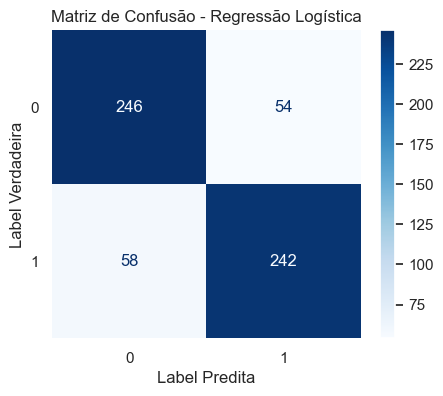

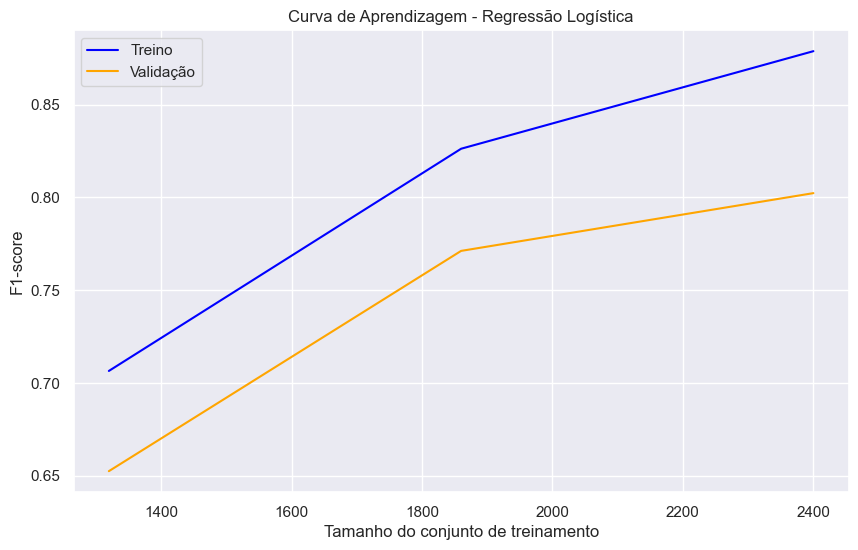


Métricas médias (5 folds):
Accuracy: 0.818
Precision: 0.832
Recall: 0.797
F1: 0.814
AUC: 0.905


In [19]:

# === Modelo único ===
classifiers = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42)
}

# === Embeddings ===
model_name = "FpOliveira/tupi-bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, use_safetensors=True)
model.eval()

def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls_last4"):
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states
        last_four = hidden_states[-4:]
        stacked = torch.stack(last_four, dim=0)
        embeddings = torch.mean(stacked, dim=0)[:, 0, :]

    return embeddings.cpu().numpy()

texts = df["text"].tolist()
labels = df["label"].values

X_embeddings = get_embeddings(texts, tokenizer, model, pooling="cls_last4")
y = labels

# === K-Fold e treino ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_name = "LogisticRegression"
clf = classifiers[clf_name]

fold_metrics = []
experiments_start_time = time.time()

for fold, (train_idx, test_idx) in enumerate(skf.split(X_embeddings, y), 1):
    X_train, X_test = X_embeddings[train_idx], X_embeddings[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Probabilidades para AUC
    y_scores = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_scores)

    fold_metrics.append([acc, prec, rec, f1, auc])

    print(f"Fold {fold} - Acc: {acc:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")

    # === Matriz de confusão do último fold ===
    if fold == skf.get_n_splits():
        cm = confusion_matrix(y_test, y_pred)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        fig, ax = plt.subplots(figsize=(5, 4))
        disp.plot(cmap="Blues", ax=ax)

        # Remover linhas internas (quadradinhos)
        ax.grid(False)

        # Remover bordas externas
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Renomear eixos (opcional)
        ax.set_xlabel("Label Predita")
        ax.set_ylabel("Label Verdadeira")

        plt.title("Matriz de Confusão - Regressão Logística")
        plt.show()


# === Curva de aprendizagem ===
train_sizes, train_scores, val_scores = learning_curve(
    clf, X_embeddings, y, cv=5, scoring="f1", n_jobs=-1
)
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color="blue", label="Treino")
plt.plot(train_sizes, val_mean, color="orange", label="Validação")
plt.xlabel("Tamanho do conjunto de treinamento")
plt.ylabel("F1-score")
plt.title("Curva de Aprendizagem - Regressão Logística")
plt.legend()
plt.grid(True)
plt.show()


# === Métricas médias ===
fold_metrics = np.array(fold_metrics)
mean_metrics = np.mean(fold_metrics, axis=0)
print("\nMétricas médias (5 folds):")
print(f"Accuracy: {mean_metrics[0]:.3f}")
print(f"Precision: {mean_metrics[1]:.3f}")
print(f"Recall: {mean_metrics[2]:.3f}")
print(f"F1: {mean_metrics[3]:.3f}")
print(f"AUC: {mean_metrics[4]:.3f}")


### Melhor resultado - inglÊs

Fold 1 - Acc: 0.813, F1: 0.808, AUC: 0.905
Fold 2 - Acc: 0.830, F1: 0.823, AUC: 0.914
Fold 3 - Acc: 0.830, F1: 0.828, AUC: 0.914
Fold 4 - Acc: 0.802, F1: 0.797, AUC: 0.897
Fold 5 - Acc: 0.813, F1: 0.812, AUC: 0.892


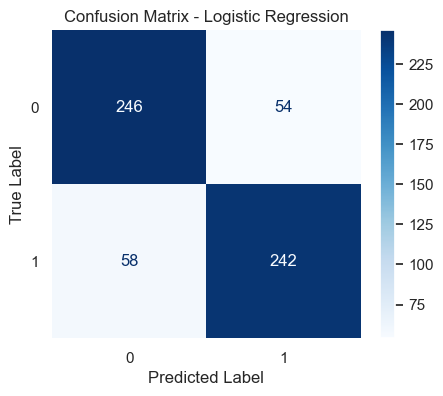

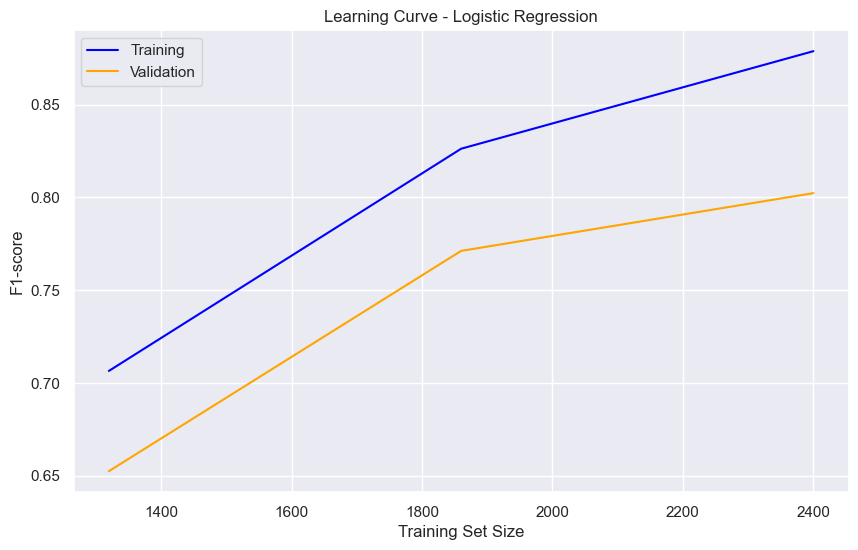


Métricas médias (5 folds):
Accuracy: 0.818
Precision: 0.832
Recall: 0.797
F1: 0.814
AUC: 0.905


In [20]:

# === Modelo único ===
classifiers = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42)
}

# === Embeddings ===
model_name = "FpOliveira/tupi-bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, use_safetensors=True)
model.eval()

def get_embeddings(texts, tokenizer, model, device="cpu", pooling="cls_last4"):
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states
        last_four = hidden_states[-4:]
        stacked = torch.stack(last_four, dim=0)
        embeddings = torch.mean(stacked, dim=0)[:, 0, :]

    return embeddings.cpu().numpy()

texts = df["text"].tolist()
labels = df["label"].values

X_embeddings = get_embeddings(texts, tokenizer, model, pooling="cls_last4")
y = labels

# === K-Fold e treino ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_name = "LogisticRegression"
clf = classifiers[clf_name]

fold_metrics = []
experiments_start_time = time.time()

for fold, (train_idx, test_idx) in enumerate(skf.split(X_embeddings, y), 1):
    X_train, X_test = X_embeddings[train_idx], X_embeddings[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Probabilidades para AUC
    y_scores = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_scores)

    fold_metrics.append([acc, prec, rec, f1, auc])

    print(f"Fold {fold} - Acc: {acc:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")

    # === Matriz de confusão do último fold ===
    if fold == skf.get_n_splits():
        cm = confusion_matrix(y_test, y_pred)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        fig, ax = plt.subplots(figsize=(5, 4))
        disp.plot(cmap="Blues", ax=ax)

        # Remover linhas internas (quadradinhos)
        ax.grid(False)

        # Remover bordas externas
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Renomear eixos (opcional)
        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("True Label")

        plt.title("Confusion Matrix - Logistic Regression")
        plt.show()


# === Curva de aprendizagem ===
train_sizes, train_scores, val_scores = learning_curve(
    clf, X_embeddings, y, cv=5, scoring="f1", n_jobs=-1
)
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color="blue", label="Training")
plt.plot(train_sizes, val_mean, color="orange", label="Validation")
plt.xlabel("Training Set Size")
plt.ylabel("F1-score")
plt.title("Learning Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()


# === Métricas médias ===
fold_metrics = np.array(fold_metrics)
mean_metrics = np.mean(fold_metrics, axis=0)
print("\nMétricas médias (5 folds):")
print(f"Accuracy: {mean_metrics[0]:.3f}")
print(f"Precision: {mean_metrics[1]:.3f}")
print(f"Recall: {mean_metrics[2]:.3f}")
print(f"F1: {mean_metrics[3]:.3f}")
print(f"AUC: {mean_metrics[4]:.3f}")
